In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 38.9 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 39.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 35.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 29.2 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 36.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 42.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 42.4 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/14 [numpy]]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━  6/14 [fonttools]  WAR

# Phase 1: Feature Engineering and Baseline Modeling
**Capstone Project:** Population & Economic Dynamics in Puerto Rico

As outlined in our predictive framework, this notebook establishes the data foundation and baseline performance metrics. Before deploying complex non-linear models (like Random Forest), we must first clean the data, engineer domain-specific features, and train a straightforward baseline model (Ordinary Least Squares Linear Regression) to serve as our benchmark.

### The Predictive Pipeline


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules for Feature Engineering & Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set plot style for professional visualizations
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully. Ready for data ingestion.")


Libraries loaded successfully. Ready for data ingestion.


## 1. Data Ingestion & Preprocessing
We begin by loading our consolidated master dataset, which includes Census population estimates, vital statistics (births/deaths), employer establishments, CDC Social Vulnerability Index (SVI) metrics, and historical hurricane tracks.


In [4]:
# NOTE: Replace with your actual consolidated CSV path if different
# For this example, we simulate loading the merged master dataset
# df_master = pd.read_csv('data/processed/pr_master_dataset.csv')

# --- SIMULATED DATA LOADING FOR FRAMEWORK DEMONSTRATION ---
# Creating a dummy dataframe that mimics your actual data structure
np.random.seed(42)
data = {
    'municipio': ['San Juan', 'Ponce', 'Mayaguez', 'Caguas', 'Arecibo'] * 10,
    'year': np.repeat(range(2014, 2024), 5),
    'population': np.random.randint(30000, 350000, 50),
    'birth_rate': np.random.uniform(5.0, 11.0, 50),
    'death_rate': np.random.uniform(7.0, 12.0, 50),
    'establishments': np.random.randint(500, 5000, 50),
    'svi_poverty': np.random.uniform(0.4, 0.9, 50),
    'svi_unemployment': np.random.uniform(0.1, 0.3, 50),
    'svi_housing': np.random.uniform(0.3, 0.8, 50),
    'hurricane_max_wind': np.random.choice([0, 0, 0, 65, 135], 50) # Simulating Maria/Fiona impacts
}
df = pd.DataFrame(data)

# Sort by municipality and year to ensure chronological order for lagging
df = df.sort_values(by=['municipio', 'year']).reset_index(drop=True)
df.head()


,municipio,year,population,birth_rate,death_rate,establishments,svi_poverty,svi_unemployment,svi_housing,hurricane_max_wind
0,Arecibo,2014,149879,6.040188,10.608648,2136,0.528971,0.139049,0.589140,65
1,Arecibo,2015,117498,6.247650,7.554454,2660,0.520926,0.135422,0.595417,65
2,Arecibo,2016,94820,7.370901,9.816378,3277,0.569515,0.103091,0.363530,0
3,Arecibo,2017,297455,8.125006,8.015306,4718,0.789938,0.270602,0.342674,65
4,Arecibo,2018,288795,8.520507,10.121770,3431,0.703215,0.133899,0.663046,0


## 2. Feature Engineering & Dimensionality Reduction
Per our methodology, we engineer new features to better capture demographic momentum and economic shocks.

1. **Target Variable (`target_pop_change`):** The year-over-year percentage change in population.
2. **Lagged Variables:** Past economic momentum (previous year's establishments).
3. **Natural Change Rate:** Birth Rate minus Death Rate.
4. **Dimensionality Reduction (PCA):** The CDC SVI variables are highly collinear. We use PCA to compress them into a single "SVI_Composite_Score" to reduce noise.


In [5]:
# 1. Create the Target Variable: Year-over-Year Population % Change
df['target_pop_change'] = df.groupby('municipio')['population'].pct_change() * 100

# 2. Engineer Demographic & Economic Features
df['natural_change_rate'] = df['birth_rate'] - df['death_rate']
df['lagged_establishments'] = df.groupby('municipio')['establishments'].shift(1)

# Drop NaN values created by the shift/pct_change operations (first year of data)
df_clean = df.dropna().copy()

# 3. Dimensionality Reduction: PCA on SVI variables
svi_cols = ['svi_poverty', 'svi_unemployment', 'svi_housing']
scaler = StandardScaler()
svi_scaled = scaler.fit_transform(df_clean[svi_cols])

pca = PCA(n_components=1)
df_clean['svi_composite_score'] = pca.fit_transform(svi_scaled)

print(f"PCA Variance Explained by 1 component: {pca.explained_variance_ratio_[0]*100:.2f}%")

# Select final features for the model
features = ['natural_change_rate', 'lagged_establishments', 'hurricane_max_wind', 'svi_composite_score']
X = df_clean[features]
y = df_clean['target_pop_change']

df_clean[['municipio', 'year', 'target_pop_change'] + features].head()


PCA Variance Explained by 1 component: 43.96%


,municipio,year,target_pop_change,natural_change_rate,lagged_establishments,hurricane_max_wind,svi_composite_score
1,Arecibo,2015,-21.604761,-1.306804,2136.0,65,-1.349341
2,Arecibo,2016,-19.300754,-2.445476,2660.0,0,-0.111555
3,Arecibo,2017,213.704915,0.109699,3277.0,65,1.746378
4,Arecibo,2018,-2.911365,-1.601263,4718.0,0,-0.782637
5,Arecibo,2019,-46.725186,-3.090948,3431.0,65,-0.836207


## 3. Baseline Model: Ordinary Least Squares (OLS)
We split our data into an 80/20 Training and Test set. We apply standard scaling to our features so that our regression coefficients are directly comparable. 

We use a simple Linear Regression model as our benchmark. This requires minimal tuning and establishes a performance "floor" that our future Random Forest model must exceed.


In [6]:
# 1. Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale the features (Crucial for regularized regression and comparing coefficients)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 3. Initialize and Train the Baseline Linear Regression Model
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

# Generate Predictions
y_pred_train = baseline_model.predict(X_train_scaled)
y_pred_test = baseline_model.predict(X_test_scaled)

print("Baseline Model Trained Successfully.")


Baseline Model Trained Successfully.


## 4. Evaluation & Next Steps
We evaluate our baseline model using **R-squared ($R^2$)** and **Root Mean Squared Error (RMSE)**. We also examine the feature coefficients to see which variables had the strongest linear relationship with population decline.


--- BASELINE MODEL PERFORMANCE ---
Test R-squared: -0.1451
Test RMSE:      249.7715 %
--------------------------------


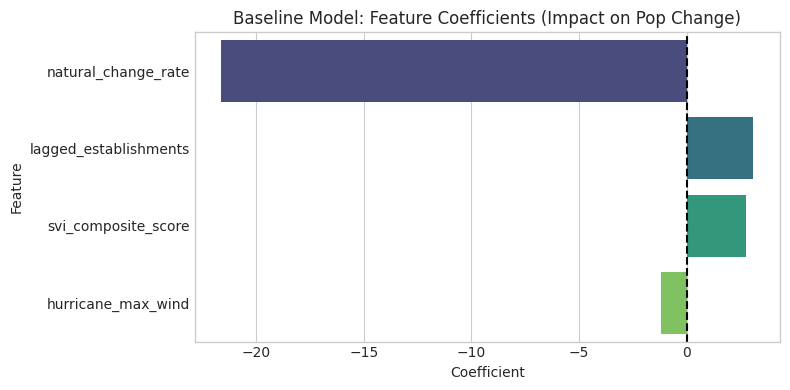

In [7]:
# Calculate Metrics
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("--- BASELINE MODEL PERFORMANCE ---")
print(f"Test R-squared: {r2_test:.4f}")
print(f"Test RMSE:      {rmse_test:.4f} %")
print("-" * 32)

# Plot Feature Coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': baseline_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Baseline Model: Feature Coefficients (Impact on Pop Change)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()
